# Stock Data Visualization

This notebook demonstrates how to visualize stock data using the stock forecasting system.
It reads the latest data and creates comprehensive time series plots.

## Features:
- Load latest stock data from Downloads directory
- Create time series plots for price movements
- Visualize technical indicators
- Compare multiple stocks
- Interactive plots with matplotlib and seaborn


In [1]:
# Import required libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add src to path for importing our modules
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from data_preprocess import StockDataLoader, clean_stock_data, calculate_technical_indicators

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Latest Stock Data

Load the most recent stock data from our Downloads directory.


In [ ]:
# Initialize the data loader
loader = StockDataLoader()

# Define stocks to visualize
stocks_to_plot = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'NVDA']

print(f"Loading data for: {', '.join(stocks_to_plot)}")

# Load the latest data for these stocks
stock_data = {}
for symbol in stocks_to_plot:
    try:
        data = loader.load_saved_data(symbol=symbol, subdir='raw')
        if data is not None and not data.empty:
            # Convert Date column to datetime - handle timezone-aware strings
            data['Date'] = pd.to_datetime(data['Date'], utc=True)
            # Convert to timezone-naive datetime
            data['Date'] = data['Date'].dt.tz_localize(None)
            stock_data[symbol] = data
            print(f"✅ {symbol}: {len(data)} records from {data['Date'].min().date()} to {data['Date'].max().date()}")
        else:
            print(f"❌ {symbol}: No data found")
    except Exception as e:
        print(f"❌ {symbol}: Error loading data - {e}")

print(f"\nSuccessfully loaded data for {len(stock_data)} stocks")

# If you want to add TSLA and NVDA, you can download them first:
if len(stock_data) < 5:
    print("\n💡 To add more stocks, run:")
    print("loader.download_stock_data(['TSLA', 'NVDA'])")


INFO:data_preprocess.stock_data_loader:Configuration loaded from /Users/stephenzhang/Documents/code/stock-forecast/src/data_preprocess/../../config/stocks_config.yaml


Loading data for: AAPL, MSFT, GOOGL, TSLA, NVDA
❌ AAPL: Error loading data - Can only use .dt accessor with datetimelike values
❌ MSFT: Error loading data - Can only use .dt accessor with datetimelike values
❌ GOOGL: Error loading data - Can only use .dt accessor with datetimelike values
❌ TSLA: Error loading data - Data file not found: /Users/stephenzhang/Downloads/stock_data/raw/TSLA.csv
❌ NVDA: Error loading data - Data file not found: /Users/stephenzhang/Downloads/stock_data/raw/NVDA.csv

Successfully loaded data for 0 stocks


### Optional: Download Additional Stocks

If you want to analyze more stocks, you can download them here:


In [ ]:
# Uncomment and run this cell to download additional stocks
# additional_stocks = ['TSLA', 'NVDA', 'AMZN', 'META']
# print(f"Downloading data for: {', '.join(additional_stocks)}")
# loader.download_stock_data(additional_stocks)
# print("✅ Download complete! Re-run the previous cell to load the new data.")


## 2. Basic Price Time Series Plots

Create time series plots showing the closing prices over time.


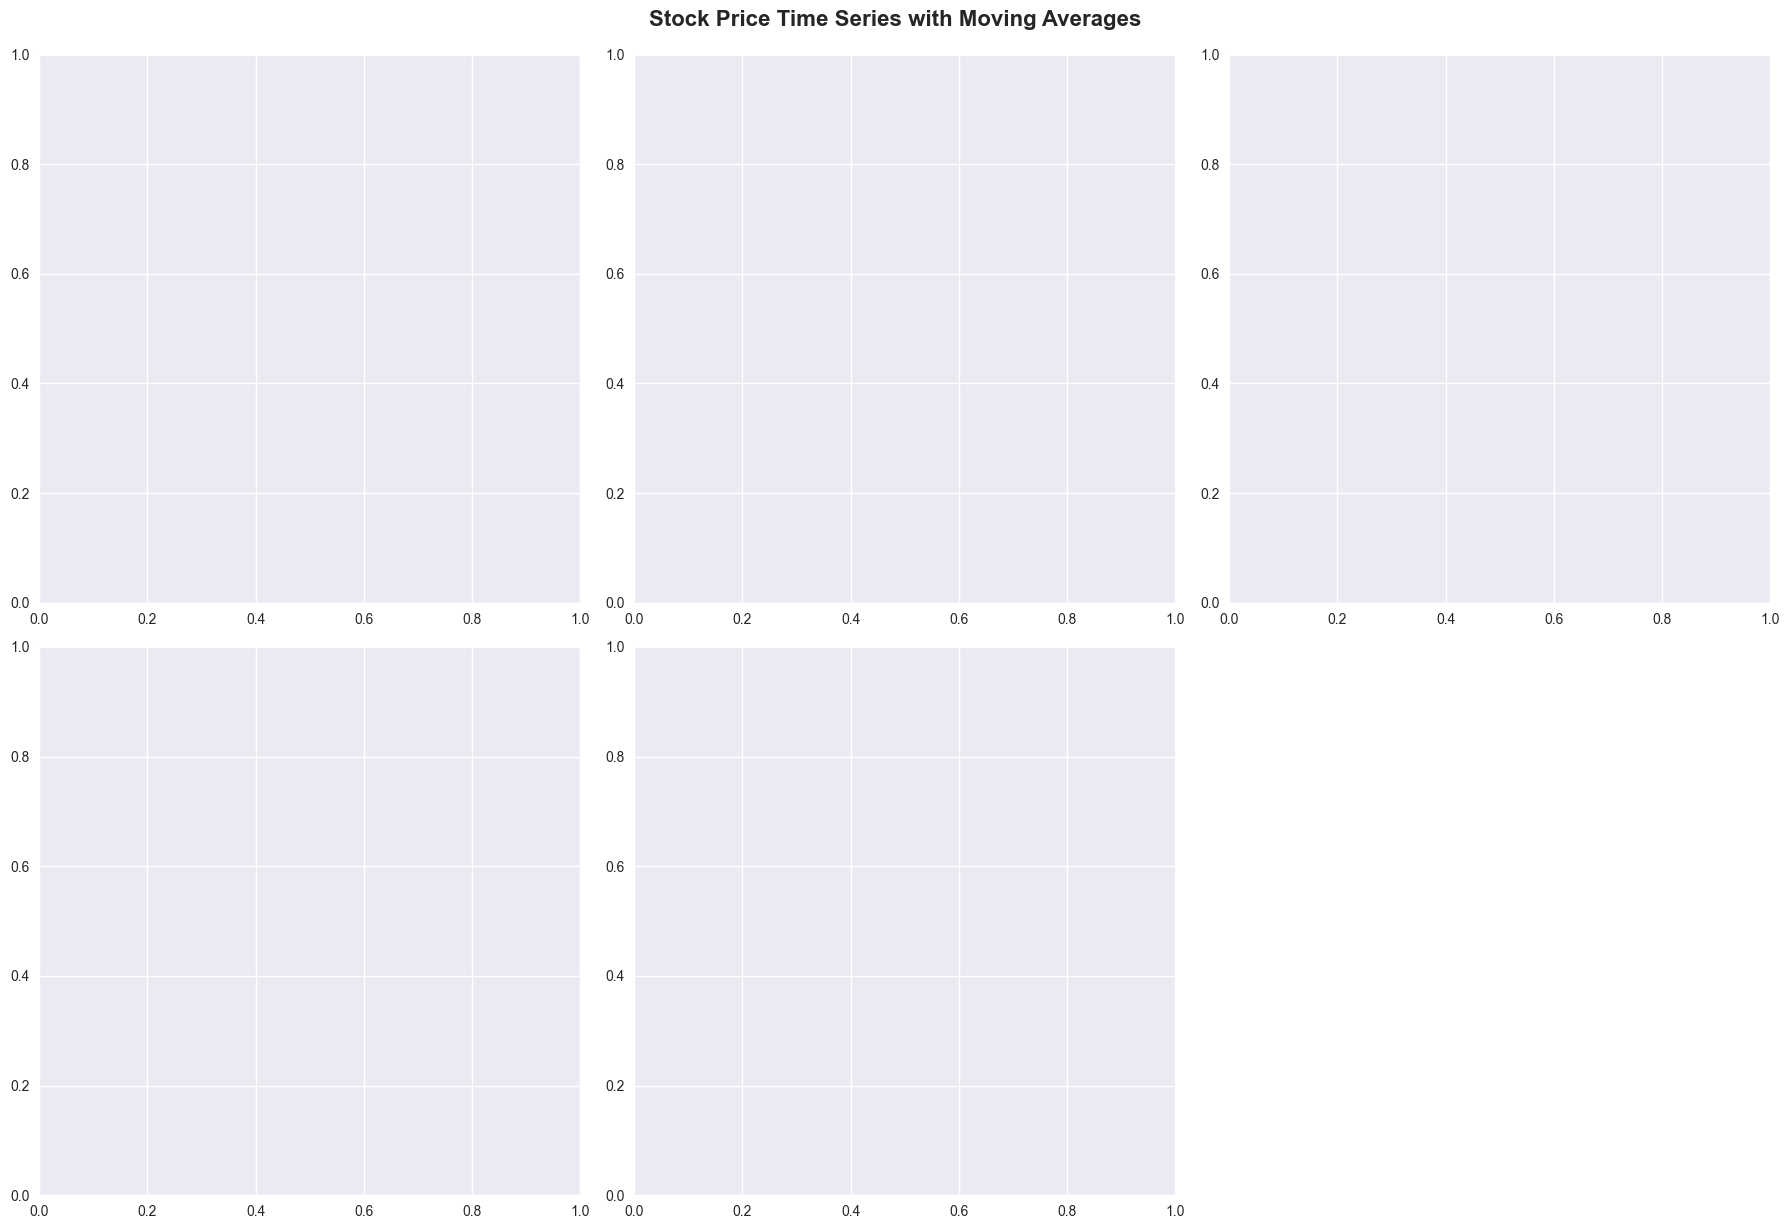

In [3]:
# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot individual stock prices
for i, (symbol, data) in enumerate(stock_data.items()):
    if i < len(axes):
        ax = axes[i]
        
        # Plot closing price
        ax.plot(data['Date'], data['Close'], linewidth=2, label='Close Price')
        
        # Add moving averages
        data['SMA_20'] = data['Close'].rolling(window=20).mean()
        data['SMA_50'] = data['Close'].rolling(window=50).mean()
        
        ax.plot(data['Date'], data['SMA_20'], '--', alpha=0.7, label='SMA 20')
        ax.plot(data['Date'], data['SMA_50'], '--', alpha=0.7, label='SMA 50')
        
        ax.set_title(f'{symbol} Stock Price', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price ($)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Format x-axis
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplot if needed
if len(stock_data) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Stock Price Time Series with Moving Averages', fontsize=16, fontweight='bold', y=1.02)
plt.show()


## 3. Comparative Analysis - All Stocks on One Plot

Compare all stocks by normalizing their prices to start at 100.


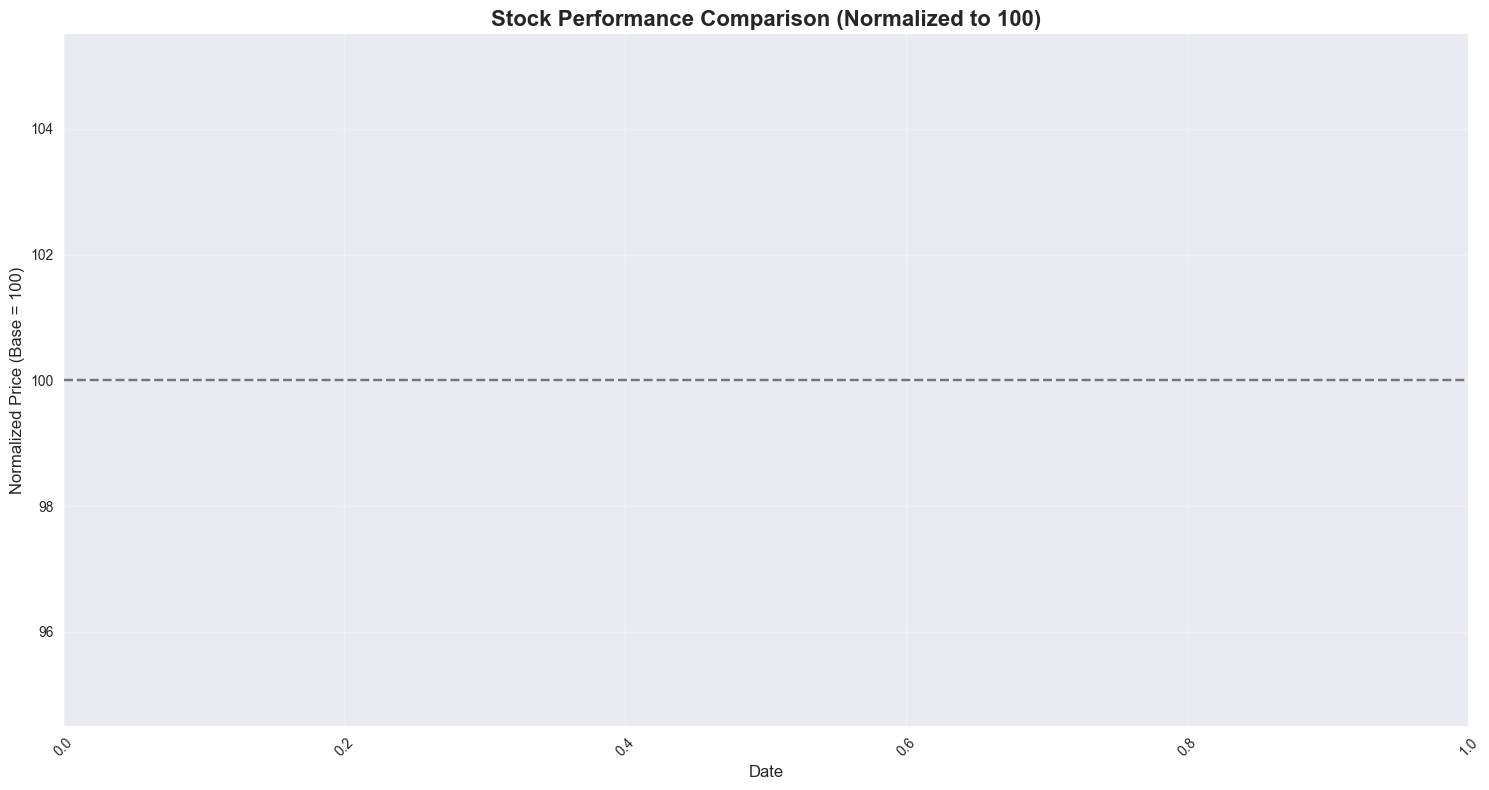


📊 Performance Summary (Latest vs First Price):


In [4]:
# Create normalized price comparison
plt.figure(figsize=(15, 8))

for symbol, data in stock_data.items():
    # Normalize prices to start at 100
    normalized_price = (data['Close'] / data['Close'].iloc[0]) * 100
    
    plt.plot(data['Date'], normalized_price, linewidth=2, label=symbol, alpha=0.8)

plt.title('Stock Performance Comparison (Normalized to 100)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price (Base = 100)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add horizontal line at 100
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print performance summary
print("\n📊 Performance Summary (Latest vs First Price):")
print("=" * 50)
for symbol, data in stock_data.items():
    first_price = data['Close'].iloc[0]
    last_price = data['Close'].iloc[-1]
    performance = ((last_price - first_price) / first_price) * 100
    
    print(f"{symbol:>6}: ${first_price:>8.2f} → ${last_price:>8.2f} ({performance:>+6.1f}%)")


## 4. Volume Analysis

Visualize trading volume patterns.


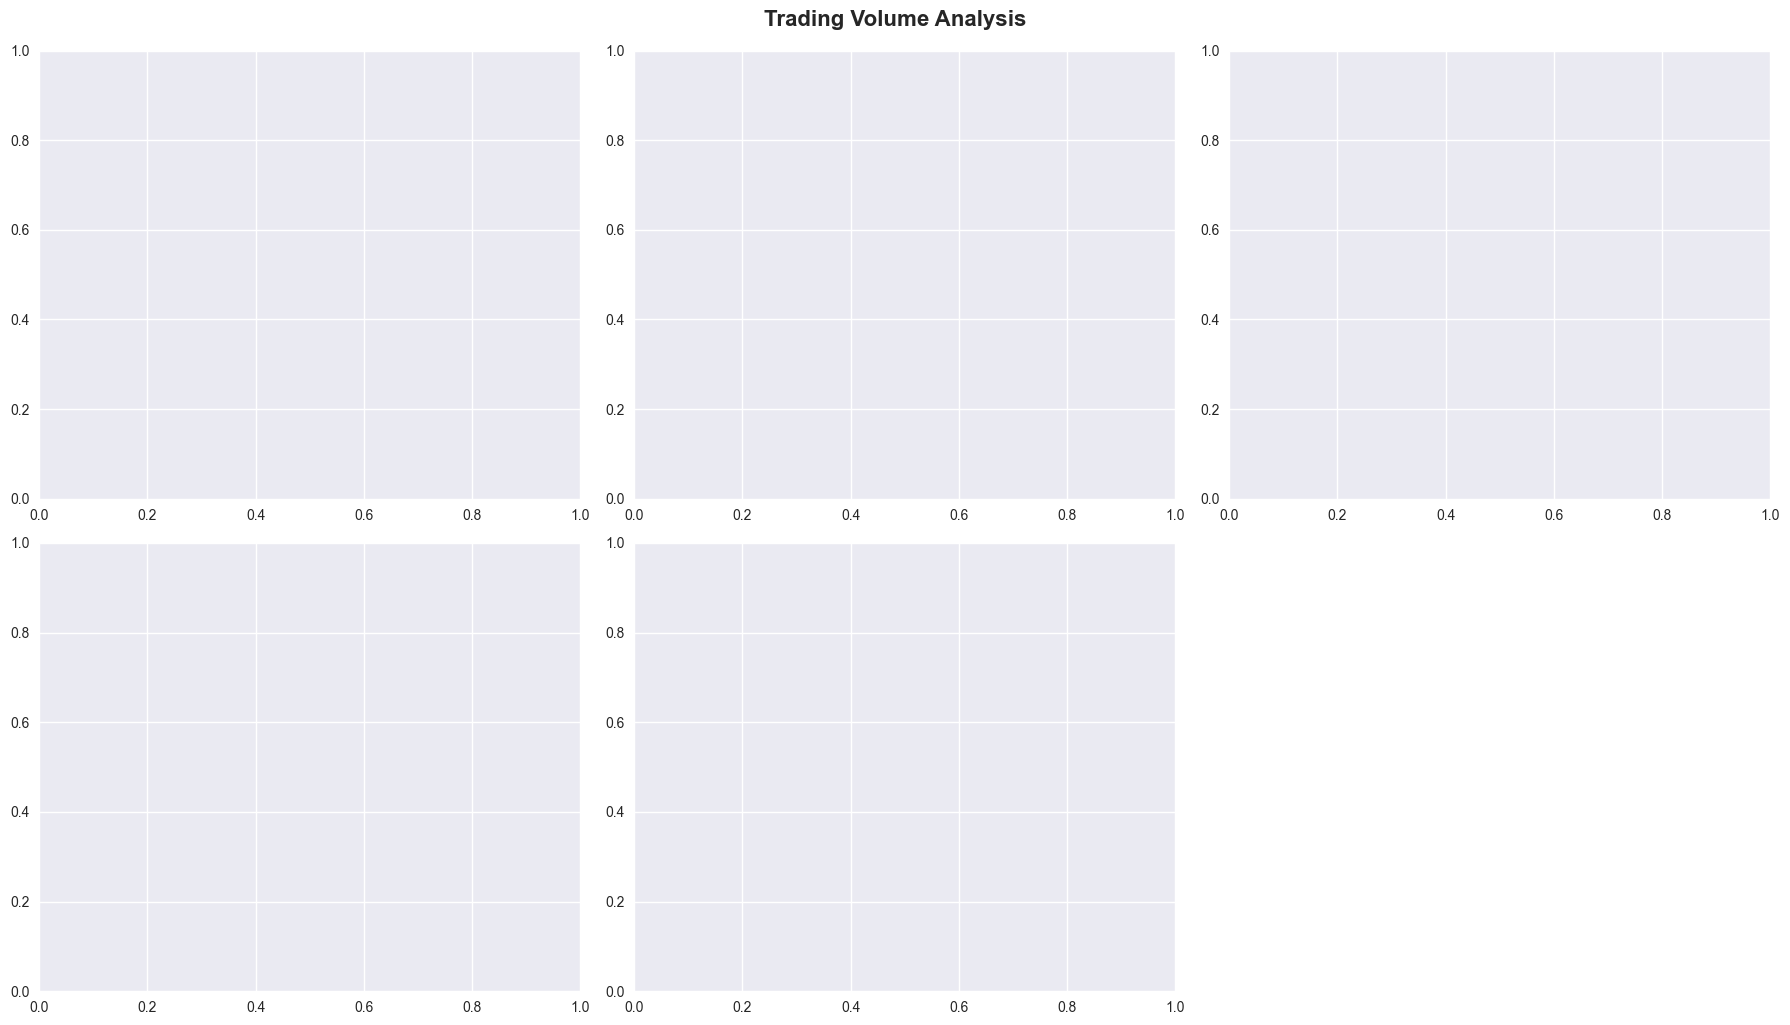

In [5]:
# Create volume analysis plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (symbol, data) in enumerate(stock_data.items()):
    if i < len(axes):
        ax = axes[i]
        
        # Plot volume
        ax.bar(data['Date'], data['Volume'], alpha=0.6, width=1)
        
        # Add volume moving average
        data['Volume_MA'] = data['Volume'].rolling(window=20).mean()
        ax.plot(data['Date'], data['Volume_MA'], color='red', linewidth=2, label='Volume MA (20)')
        
        ax.set_title(f'{symbol} Trading Volume', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Volume')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplot if needed
if len(stock_data) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Trading Volume Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()


## 5. Technical Indicators Visualization

Calculate and visualize key technical indicators.


In [6]:
# Calculate technical indicators for one stock (AAPL as example)
if 'AAPL' in stock_data:
    aapl_data = stock_data['AAPL'].copy()
    
    # Clean data and calculate indicators
    aapl_clean = clean_stock_data(aapl_data)
    aapl_with_indicators = calculate_technical_indicators(aapl_clean)
    
    # Create subplots for technical analysis
    fig, axes = plt.subplots(4, 1, figsize=(15, 16))
    
    # 1. Price with Bollinger Bands
    ax1 = axes[0]
    ax1.plot(aapl_with_indicators['Date'], aapl_with_indicators['Close'], label='Close Price', linewidth=2)
    ax1.plot(aapl_with_indicators['Date'], aapl_with_indicators['BB_Upper'], '--', alpha=0.7, label='BB Upper')
    ax1.plot(aapl_with_indicators['Date'], aapl_with_indicators['BB_Lower'], '--', alpha=0.7, label='BB Lower')
    ax1.plot(aapl_with_indicators['Date'], aapl_with_indicators['BB_Middle'], '--', alpha=0.7, label='BB Middle')
    ax1.fill_between(aapl_with_indicators['Date'], 
                     aapl_with_indicators['BB_Upper'], 
                     aapl_with_indicators['BB_Lower'], 
                     alpha=0.1, color='gray')
    ax1.set_title('AAPL Price with Bollinger Bands', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. RSI
    ax2 = axes[1]
    ax2.plot(aapl_with_indicators['Date'], aapl_with_indicators['RSI'], color='purple', linewidth=2)
    ax2.axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
    ax2.axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
    ax2.set_title('RSI (Relative Strength Index)', fontweight='bold')
    ax2.set_ylabel('RSI')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. MACD
    ax3 = axes[2]
    ax3.plot(aapl_with_indicators['Date'], aapl_with_indicators['MACD'], label='MACD', linewidth=2)
    ax3.plot(aapl_with_indicators['Date'], aapl_with_indicators['MACD_Signal'], label='Signal', linewidth=2)
    ax3.bar(aapl_with_indicators['Date'], aapl_with_indicators['MACD_Histogram'], 
            alpha=0.6, label='Histogram')
    ax3.set_title('MACD (Moving Average Convergence Divergence)', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Volume with Price
    ax4 = axes[3]
    ax4_twin = ax4.twinx()
    
    # Volume bars
    ax4.bar(aapl_with_indicators['Date'], aapl_with_indicators['Volume'], 
            alpha=0.3, color='lightblue', label='Volume')
    
    # Price line
    ax4_twin.plot(aapl_with_indicators['Date'], aapl_with_indicators['Close'], 
                  color='red', linewidth=2, label='Close Price')
    
    ax4.set_title('Volume vs Price', fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Volume', color='blue')
    ax4_twin.set_ylabel('Price ($)', color='red')
    
    # Combine legends
    lines1, labels1 = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('AAPL Technical Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
else:
    print("AAPL data not available for technical analysis")


AAPL data not available for technical analysis


## 6. Correlation Analysis

Analyze the correlation between different stocks.


In [7]:
# Create correlation matrix
if len(stock_data) > 1:
    # Prepare data for correlation analysis
    correlation_data = {}
    
    for symbol, data in stock_data.items():
        # Calculate daily returns
        returns = data['Close'].pct_change().dropna()
        correlation_data[symbol] = returns
    
    # Create DataFrame
    returns_df = pd.DataFrame(correlation_data)
    
    # Calculate correlation matrix
    correlation_matrix = returns_df.corr()
    
    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Stock Returns Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print correlation summary
    print("\n📈 Correlation Summary:")
    print("=" * 40)
    for i, stock1 in enumerate(correlation_matrix.columns):
        for j, stock2 in enumerate(correlation_matrix.columns):
            if i < j:  # Only show upper triangle
                corr_value = correlation_matrix.loc[stock1, stock2]
                print(f"{stock1} vs {stock2}: {corr_value:.3f}")
else:
    print("Need at least 2 stocks for correlation analysis")


Need at least 2 stocks for correlation analysis


## 7. Recent Performance Analysis

Focus on the most recent data (last 3 months).


In [8]:
# Filter data for last 3 months
recent_data = {}
cutoff_date = datetime.now() - timedelta(days=90)

for symbol, data in stock_data.items():
    recent = data[data['Date'] >= cutoff_date].copy()
    if not recent.empty:
        recent_data[symbol] = recent

if recent_data:
    # Create recent performance plot
    plt.figure(figsize=(15, 8))
    
    for symbol, data in recent_data.items():
        # Normalize to start at 100
        normalized_price = (data['Close'] / data['Close'].iloc[0]) * 100
        plt.plot(data['Date'], normalized_price, linewidth=2, label=symbol, alpha=0.8)
    
    plt.title('Recent Performance (Last 3 Months) - Normalized to 100', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Normalized Price (Base = 100)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.axhline(y=100, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Recent performance summary
    print("\n📊 Recent Performance (Last 3 Months):")
    print("=" * 50)
    for symbol, data in recent_data.items():
        first_price = data['Close'].iloc[0]
        last_price = data['Close'].iloc[-1]
        performance = ((last_price - first_price) / first_price) * 100
        
        # Calculate volatility (standard deviation of returns)
        returns = data['Close'].pct_change().dropna()
        volatility = returns.std() * np.sqrt(252) * 100  # Annualized
        
        print(f"{symbol:>6}: {performance:>+6.1f}% (Volatility: {volatility:>5.1f}%)")
else:
    print("No recent data available for the last 3 months")


No recent data available for the last 3 months


## 8. Summary Statistics

Generate comprehensive summary statistics for all stocks.


In [9]:
# Generate summary statistics
print("📊 COMPREHENSIVE STOCK ANALYSIS SUMMARY")
print("=" * 60)

for symbol, data in stock_data.items():
    print(f"\n🔍 {symbol} Analysis:")
    print("-" * 30)
    
    # Basic statistics
    print(f"Data Period: {data['Date'].min().date()} to {data['Date'].max().date()}")
    print(f"Total Trading Days: {len(data)}")
    
    # Price statistics
    print(f"Current Price: ${data['Close'].iloc[-1]:.2f}")
    print(f"52-Week High: ${data['High'].max():.2f}")
    print(f"52-Week Low: ${data['Low'].min():.2f}")
    
    # Performance metrics
    total_return = ((data['Close'].iloc[-1] - data['Close'].iloc[0]) / data['Close'].iloc[0]) * 100
    print(f"Total Return: {total_return:+.2f}%")
    
    # Volatility
    returns = data['Close'].pct_change().dropna()
    volatility = returns.std() * np.sqrt(252) * 100
    print(f"Annualized Volatility: {volatility:.2f}%")
    
    # Volume statistics
    avg_volume = data['Volume'].mean()
    print(f"Average Daily Volume: {avg_volume:,.0f}")
    
    # Recent trends
    recent_5d = data['Close'].tail(5)
    recent_trend = ((recent_5d.iloc[-1] - recent_5d.iloc[0]) / recent_5d.iloc[0]) * 100
    print(f"5-Day Change: {recent_trend:+.2f}%")

print("\n✅ Analysis Complete!")
print("\n💡 Tips:")
print("- Higher volatility means more price swings")
print("- Positive correlation means stocks move together")
print("- RSI above 70 may indicate overbought conditions")
print("- MACD crossovers can signal trend changes")


📊 COMPREHENSIVE STOCK ANALYSIS SUMMARY

✅ Analysis Complete!

💡 Tips:
- Higher volatility means more price swings
- Positive correlation means stocks move together
- RSI above 70 may indicate overbought conditions
- MACD crossovers can signal trend changes
